# Kuiper statistic analysis

In this notebook, I compare the Kuiper statistics between daily maximum values / anomalies and bootstrapped Kuiper statistics from both stationary and fitted parameter values. The goal is to show that all of these are too similar to rule out, which lets us use a GEV distribution to characterize trends in extreme temperatures.

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from config import DATA_ROOT
from src.utils import compute_ecdf

# import custom stuff
from src.plotting_presets import get_presets

# import custom stuff
from ambpy.plotutils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

In [14]:
anom_type = 'annmean'
tmin = 1979

In [15]:
if anom_type != 'raw':
    anom_type = f'anom_{anom_type}'

In [4]:
ds_max = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_t2m_annual_max_1deg_landonly_gev_stat_TMIN{tmin}_{anom_type}_kuiper.nc', engine='netcdf4')
ds_boot = xr.open_dataset(DATA_ROOT / 'stats' /f'bootstrapped_ks_{tmin}.nc', engine='netcdf4')

In [5]:
ds_max

<xarray.Dataset>
Dimensions:             (year: 46, lat: 180, lon: 360)
Coordinates:
  * lat                 (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon                 (lon) int64 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
  * year                (year) int64 1979 1980 1981 1982 ... 2021 2022 2023 2024
Data variables:
    t2m                 (year, lat, lon) float32 ...
    t2m_anom_annmean    (year, lat, lon) float32 ...
    t2m_anom_trend      (year, lat, lon) float64 ...
    loc_anom_annmean    (lat, lon) float64 ...
    scale_anom_annmean  (lat, lon) float64 ...
    shape_anom_annmean  (lat, lon) float64 ...
    obs_k_anom_annmean  (lat, lon) float64 ...
    syn_k_anom_annmean  (lat, lon) float64 ...
Attributes:
    MLE_success_rate:  1.0

In [6]:
ds_boot

<xarray.Dataset>
Dimensions:  (iter: 1000)
Coordinates:
  * iter     (iter) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
Data variables:
    boot_ks  (iter) float64 ...
Attributes:
    shape:    -0.25
    loc:      20.0
    scale:    1.5

## Kuiper statistic CDFs

In [11]:
def plot_kuiper_max_min_ecdf(ds_max, ds_boot, k_type, k_max, xlim=False,
                             filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_' + k_type].values.flatten()

    # ignore -1 values (ocean)
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < k_max)]
    syn_k_max = syn_k_max[(syn_k_max >= 0.0) & (syn_k_max < k_max)]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    obs_k_max_cdf, obs_k_max_probs = compute_ecdf(obs_k_max, extend_lower=True, extend_upper=False)
    syn_k_max_cdf, syn_k_max_probs = compute_ecdf(syn_k_max, extend_lower=True, extend_upper=False)
    
    boot_k_cdf, boot_k_probs = compute_ecdf(boot_k, extend_lower=True, extend_upper=True,
                                            ub=max(max(syn_k_max_cdf), max(obs_k_max_cdf)))

    # create figure
    fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

    # first panel: maximum temperatures
    ax.plot(obs_k_max_cdf, obs_k_max_probs, label='ERA5',
              linewidth=3)
    ax.plot(syn_k_max_cdf, syn_k_max_probs, label='Bootstrapped,\nfitted parameters',
              linewidth=2, linestyle='dashed')
    ax.plot(boot_k_cdf, boot_k_probs, label='Bootstrapped,\narbitrary parameters',
              linewidth=2, linestyle='dotted')
    
    ax.set_xlabel('Kuiper statistic')
    ax.legend(loc='lower right')
    
    ax.set_ylabel('CDF')

    if xlim:
        ax.set_xlim((0, k_max))

    # add labels
    # label physical distance in and down:
    trans = mtransforms.ScaledTranslation(0, 0.0, fig.dpi_scale_trans)
    ax.text(0.05, 0.97, 'A', transform=ax.transAxes + trans, fontsize=20, fontweight='bold',
            verticalalignment='top', bbox=dict(facecolor='none', edgecolor='none', pad=1))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print(f'Figure saved to: {make_figure_filename(*filename_args)}')

Figure saved to: figs/2026-03-30-kuiper_max_anom_annmean_tmin1979.png


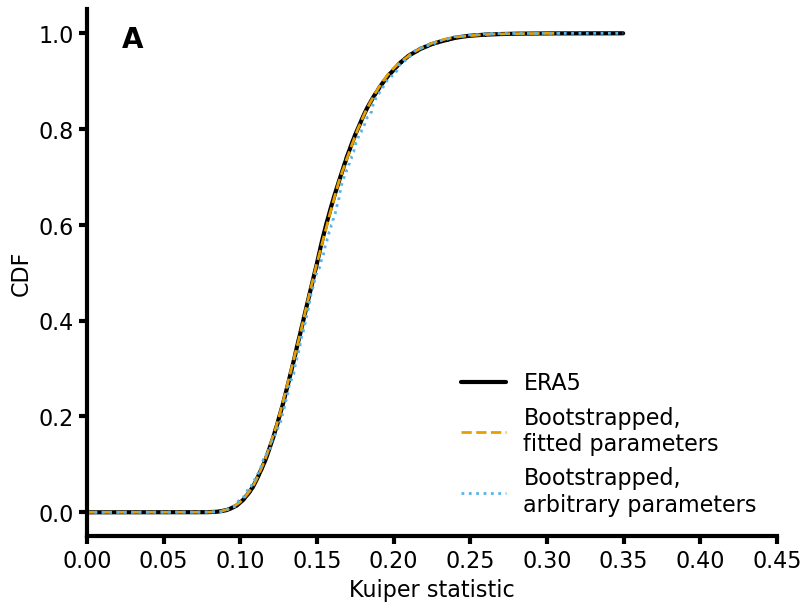

In [17]:
plot_kuiper_max_min_ecdf(ds_max, ds_boot, anom_type, k_max=0.45, 
                         xlim=True, filename_args=[f'kuiper_max_{anom_type}_tmin{tmin}', 'png', 'figs'])
plt.show()

Figure saved!


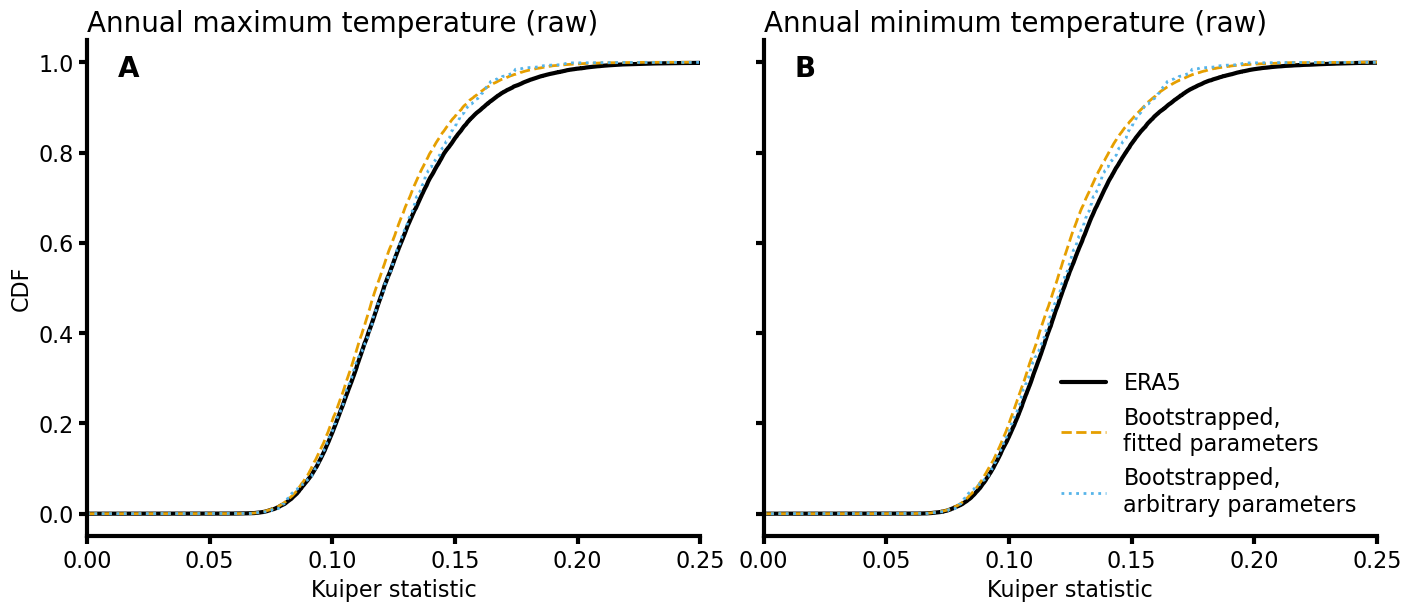

In [60]:
plot_kuiper_max_min_ecdf(ds_max, ds_min, ds_boot, 'raw', xlim=True, filename_args=['kuiper-daily-max-raw-ecdf', 'png', 'figs'])

Figure saved!


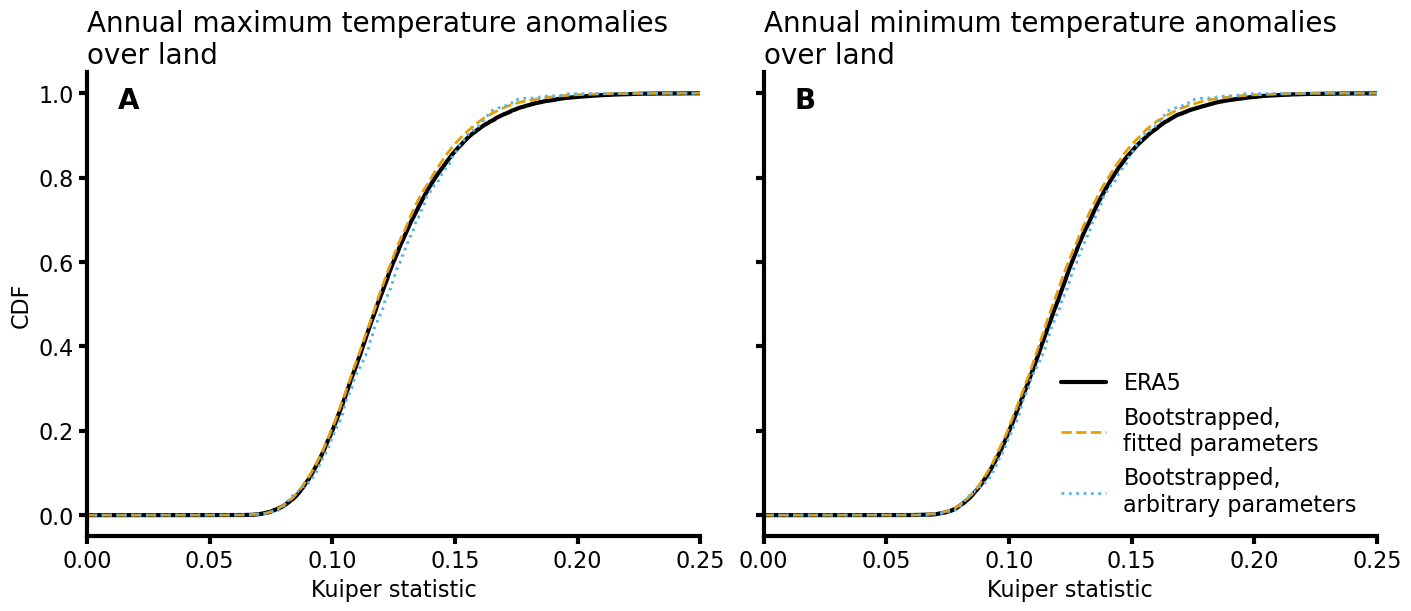

In [62]:
plot_kuiper_max_min_ecdf(ds_max, ds_min, ds_boot, 'anom', xlim=True, filename_args=['kuiper-daily-max-anom-ecdf', 'png', 'figs'])

## GEV parameter maps

In [84]:
def plot_gev_parameters(shape, loc, scale, k, titles=None, suptitle=None, save_fig=True,
                        filename_args=['gev-k', 'png', 'figs']):
    """
    Plot four xarray DataArrays (shape, loc, scale, k) on a 2x2 world map grid.

    Parameters
    ----------
    shape, loc, scale, k : xr.DataArray
        2D DataArrays with coordinates (lat, lon)
    titles : list or tuple of str, optional
        Custom titles for the subplots. Defaults to ['Shape', 'Location', 'Scale', 'k'].
    save_fig : bool, optional
        If True, saves the figure to `fname`.
    fname : str, optional
        Output filename if save_fig=True.
    """

    if titles is None:
        titles = ["GEV Shape", "GEV Location", "GEV Scale", "Kuiper Statistic (obs)"]
        labels = titles.copy()

    else:
        labels = ["GEV Shape", "GEV Location", "GEV Scale", "Kuiper Statistic (obs)"]

    # Set up the 2x2 grid
    fig, axes = plt.subplots(
        nrows=2, ncols=2,
        figsize=(14, 8),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    params = [shape, loc, scale, k]

    for ax, da, title, label in zip(axes.flat, params, titles, labels):
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            add_colorbar=False,
            vmin=np.nanpercentile(da.values, 5),
            vmax=np.nanpercentile(da.values, 95)
        )

        # Add an aligned colorbar on the right of each plot
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label(label)

        ax.set_title(title)

    # add labels
    labels = ['A', 'B', 'C', 'D']
    ind = 0
    for a in axes.flat:
        # label physical distance in and down:
        trans = mtransforms.ScaledTranslation(0, 0.0, fig.dpi_scale_trans)
        a.text(-0.02, 1.12, labels[ind], transform=a.transAxes + trans, fontsize=20, fontweight='bold',
                verticalalignment='top', bbox=dict(facecolor='none', edgecolor='none', pad=1))
        ind += 1

    if suptitle is not None:
        fig.suptitle(suptitle)


    plt.tight_layout()
    if save_fig:
        plt.savefig(make_figure_filename(*filename_args), dpi=300, bbox_inches="tight")
        print('Figure saved!')
    plt.show()

Figure saved!


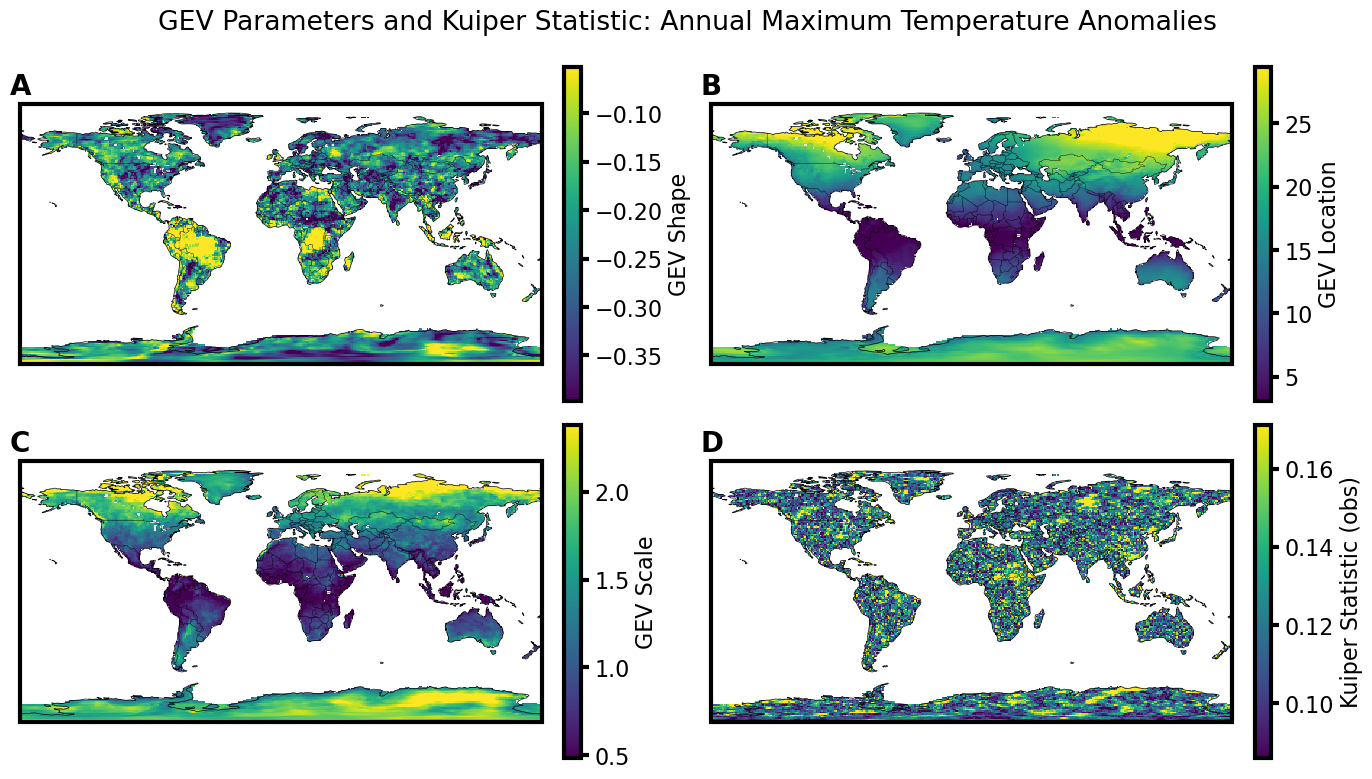

In [85]:
plot_gev_parameters(ds_max['shape_anom'],
                    ds_max['loc_anom'],
                    ds_max['scale_anom'],
                    ds_max['obs_k_anom'],
                    titles=[''] * 4,
                    suptitle="GEV Parameters and Kuiper Statistic: Annual Maximum Temperature Anomalies",
                    filename_args=['gev-kuiper-maps-annual-max-anom', 'png', 'figs'])

Figure saved!


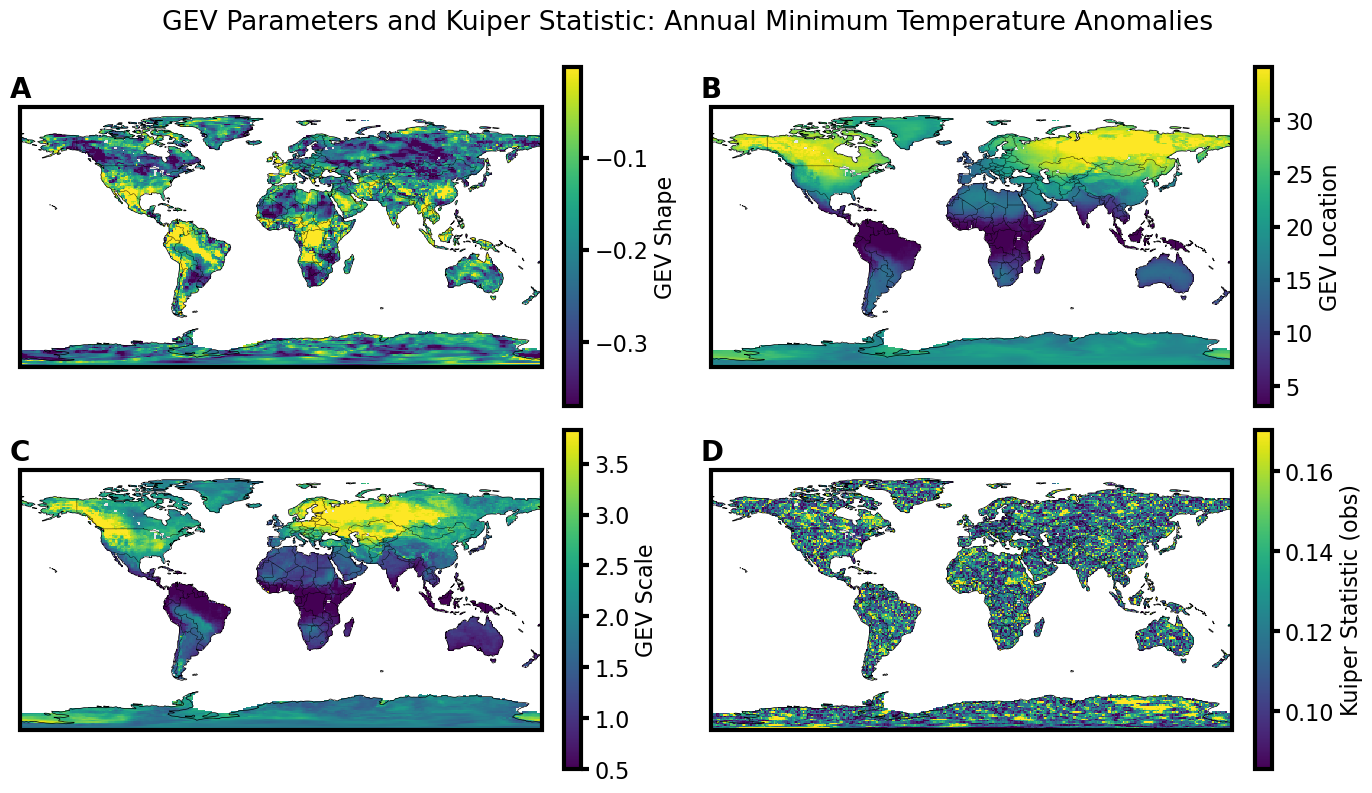

In [86]:
plot_gev_parameters(ds_min['shape_anom'],
                    ds_min['loc_anom'],
                    ds_min['scale_anom'],
                    ds_min['obs_k_anom'],
                    titles=[''] * 4,
                    suptitle="GEV Parameters and Kuiper Statistic: Annual Minimum Temperature Anomalies",
                    filename_args=['gev-kuiper-maps-annual-min', 'png', 'figs'])

# OLD

In [ ]:
def plot_kuiper_max_min(ds_max, ds_min, ds_boot, k_type, xlim=False,
                        filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_' + k_type].values.flatten()

    obs_k_min = ds_min['obs_k_' + k_type].values.flatten()
    syn_k_min = ds_min['syn_k_' + k_type].values.flatten()
    
    # ignore -1 values (ocean)
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < 1.0)]
    syn_k_max = syn_k_max[syn_k_max >= 0.0]

    # ignore -1 values (ocean)
    obs_k_min = obs_k_min[(obs_k_min >= 0.0) & (obs_k_min < 1.0)]
    syn_k_min = syn_k_min[syn_k_min >= 0.0]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    # create figure
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharey=True)

    # first panel: maximum temperatures
    ax[0].hist(obs_k_max, cumulative=True, density=True, bins=10000,
           histtype='step', label='Observations')
    ax[0].hist(syn_k_max, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, fitted parameters')
    ax[0].hist(boot_k, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, stationary parameters')

    # second panel: minimum temperatures
    ax[1].hist(obs_k_min, cumulative=True, density=True, bins=10000,
           histtype='step', label='Observations')
    ax[1].hist(syn_k_min, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, fitted parameters')
    ax[1].hist(boot_k, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, stationary parameters')
    
    for a in ax:
        a.set_xlabel('Kuiper statistic')
    
    ax[1].legend()
    
    ax[0].set_ylabel('CDF')

    if k_type == 'raw':
        ax[0].set_title("Annual maximum temperature anomalies (raw)")
        ax[1].set_title("Annual minimum temperature anomalies (raw)")
        
    elif k_type == 'anom':
        ax[0].set_title("Annual maximum temperature anomalies\nrelative to annual mean")
        ax[1].set_title("Annual minimum temperature anomalies\nrelative to annual mean")

    else:
        raise ValueError("Invalid k_type parameter passed.")

    if xlim:
        for ax in ax.flat:
            ax.set_xlim((0, 0.35))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print('Figure saved!')

In [ ]:
plot_kuiper_max_min(ds_max, ds_max, ds_boot, 'anom', xlim=True, filename_args=['kuiper-daily-max-raw', 'png', 'figs'])

In [ ]:
plot_kuiper_max_min(ds_max, ds_max, ds_boot, 'raw', xlim=True, filename_args=['kuiper-daily-max-raw', 'png', 'figs'])